<a href="https://colab.research.google.com/github/shvdkam/customer-behavior-sql-analysis/blob/main/Are_Entry_Level_Data_Analyst_Jobs_Really_Entry_Level.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re

In [ ]:
import os

print("Current directory:")
print(os.getcwd())

print("\nFiles in current directory:")
print(os.listdir())

Current directory:
/content

Files in current directory:
['.config', 'sample_data']


In [ ]:
df = pd.read_csv("/postings.csv")

print(f"Number of rows: {df.shape[0]:,}")
print(f"Number of columns: {df.shape[1]}")

df.head()

Number of rows: 12,894
Number of columns: 11


,job_title,company,job_location,job_link,first_seen,search_city,search_country,job level,job_type,job_summary,job_skills
0,"Data Analyst-SQL, Tableau",Zortech Solutions,"Mountain View, CA",https://www.linkedin.com/jobs/data-analyst-jobs,2023-12-20,Bloomington,United States,Associate,Onsite,NaN,NaN
1,Market Research & Insights Analyst,Indiana University Foundation,"Bloomington, IN",https://www.linkedin.com/jobs/view/market-rese...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Company Description\nAre you a high-performer ...,"Data analysis, Market research, Survey develop..."
2,Business Systems Analyst `1,Cook Medical,"Bloomington, IN",https://www.linkedin.com/jobs/view/business-sy...,2023-12-20,Bloomington,United States,Mid senior,Onsite,Overview\nThe Business Systems Analyst 1 perfo...,"Business Analysis, Technical Writing, Software..."
3,Senior VAT and Indirect Tax Analyst,Epic,"Bloomington, IN",https://www.linkedin.com/jobs/view/senior-vat-...,2023-12-20,Bloomington,United States,Mid senior,Onsite,We're looking for an experienced tax professio...,"Accounting, Finance, VAT/GST tax regimes, US a..."
4,Senior HRIS Analyst (Timekeeping and Payroll),Nordson Corporation,Greater Bloomington Area,https://www.linkedin.com/jobs/view/senior-hris...,2023-12-20,Bloomington,United States,Mid senior,Remote,Collaboration drives Nordson’s success as a ma...,"Workday HCM, UKG Dimensions, Ceridian Dayforce..."


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12894 entries, 0 to 12893
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       12894 non-null  object
 1   company         12894 non-null  object
 2   job_location    12894 non-null  object
 3   job_link        12894 non-null  object
 4   first_seen      12894 non-null  object
 5   search_city     12894 non-null  object
 6   search_country  12894 non-null  object
 7   job level       12894 non-null  object
 8   job_type        12894 non-null  object
 9   job_summary     12851 non-null  object
 10  job_skills      12705 non-null  object
dtypes: object(11)
memory usage: 1.1+ MB


In [ ]:
df = df.rename(columns={"job level": "job_level"})

df.columns.tolist()

['job_title',
 'company',
 'job_location',
 'job_link',
 'first_seen',
 'search_city',
 'search_country',
 'job_level',
 'job_type',
 'job_summary',
 'job_skills']

In [ ]:
df["job_level"].value_counts()

,count
job_level,
Mid senior,9691
Associate,3203


## 1. Data Understanding

Before starting the analysis, the dataset was explored to understand its structure, quality, and completeness.

The dataset contains job postings collected from online recruitment platforms. Each record includes the job title, company, location, seniority level, work arrangement, job description, and technical skills.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12894 entries, 0 to 12893
Data columns (total 11 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   job_title       12894 non-null  object
 1   company         12894 non-null  object
 2   job_location    12894 non-null  object
 3   job_link        12894 non-null  object
 4   first_seen      12894 non-null  object
 5   search_city     12894 non-null  object
 6   search_country  12894 non-null  object
 7   job_level       12894 non-null  object
 8   job_type        12894 non-null  object
 9   job_summary     12851 non-null  object
 10  job_skills      12705 non-null  object
dtypes: object(11)
memory usage: 1.1+ MB


In [ ]:
df.isna().sum()

,0
job_title,0
company,0
job_location,0
job_link,0
first_seen,0
search_city,0
search_country,0
job_level,0
job_type,0
job_summary,43


In [ ]:
df.nunique()

,0
job_title,6797
company,5283
job_location,2446
job_link,12894
first_seen,1
search_city,834
search_country,4
job_level,2
job_type,3
job_summary,11163


In [ ]:
df.describe(include="all")

,job_title,company,job_location,job_link,first_seen,search_city,search_country,job_level,job_type,job_summary,job_skills
count,12894,12894,12894,12894,12894,12894,12894,12894,12894,12851,12705
unique,6797,5283,2446,12894,1,834,4,2,3,11163,12696
top,Business Analyst,ClearanceJobs,United States,https://www.linkedin.com/jobs/view/senior-mili...,2023-12-20,Hollywood,United States,Mid senior,Onsite,We're looking for an experienced tax professio...,"Power BI, Tableau, DB2, SQL Server, Oracle, Da..."
freq,438,238,247,1,12894,150,10386,9691,6670,97,2


### Initial observations

The dataset contains job postings with different seniority levels.

Most variables are complete, with only a small number of missing values in the job summary and skills columns.

The dataset appears suitable for exploratory analysis and feature engineering.

## 2. Data Cleaning

Before the analysis, the dataset was cleaned by removing duplicate records, handling missing values, and standardizing text fields.

In [ ]:
jobs = df.copy()

In [ ]:
jobs = jobs.dropna(subset=["job_summary"])

In [ ]:
jobs = jobs.drop_duplicates(subset=["job_link"])

In [ ]:
jobs["job_summary"] = (
    jobs["job_summary"]
    .astype(str)
    .str.replace("\n", " ", regex=False)
    .str.replace("\t", " ", regex=False)
    .str.replace(r"\s+", " ", regex=True)
    .str.strip()
)

In [ ]:
jobs["job_skills"] = (
    jobs["job_skills"]
    .fillna("")
    .astype(str)
    .str.strip()
)

In [ ]:
jobs.shape

(12851, 11)

In [ ]:
jobs["job_level"].value_counts()

,count
job_level,
Mid senior,9661
Associate,3190


In [ ]:
analyst_pattern = (
    r"data analyst|"
    r"business intelligence analyst|"
    r"bi analyst|"
    r"analytics analyst|"
    r"reporting analyst|"
    r"insights analyst"
)

In [ ]:
analyst_jobs = jobs[
    jobs["job_title"]
    .str.lower()
    .str.contains(
        analyst_pattern,
        regex=True,
        na=False
    )
].copy()

In [ ]:
print(f"Number of analyst jobs: {len(analyst_jobs)}")

Number of analyst jobs: 3480


In [ ]:
analyst_jobs["job_title"].value_counts().head(20)

,count
job_title,
Data Analyst,330
Senior Data Analyst,235
Business Intelligence Analyst,142
Business Data Analyst,73
Sr. Data Analyst,52
Lead Data Analyst,38
Financial Data Analyst,37
BI Analyst,30
Senior Business Intelligence Analyst,29


## 3. Exploratory Data Analysis (EDA)

This section explores the characteristics of Data Analyst job postings, including seniority levels, work arrangements, geographical distribution, and the most frequently requested technical skills.

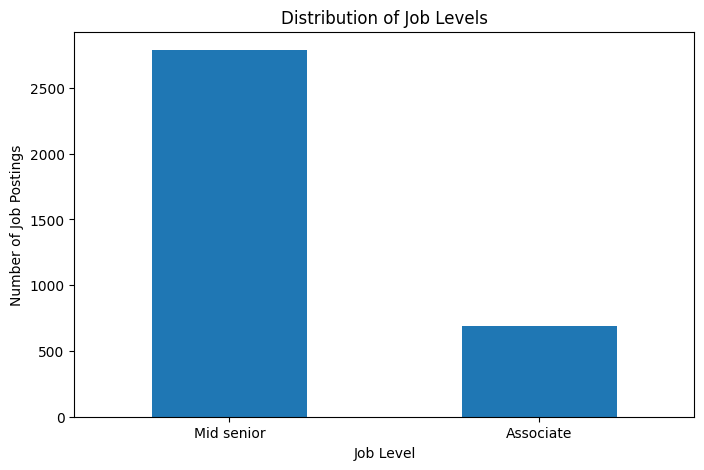

In [ ]:
analyst_jobs["job_level"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Distribution of Job Levels")
plt.xlabel("Job Level")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)

plt.show()

The majority of analyst positions belong to the Mid senior level, while Associate roles represent a smaller share of the dataset.

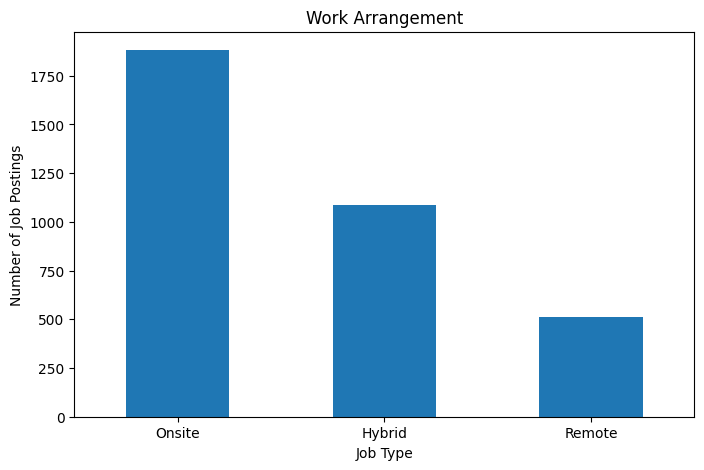

In [ ]:
analyst_jobs["job_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Work Arrangement")
plt.xlabel("Job Type")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=0)

plt.show()

Remote, Hybrid, and Onsite work arrangements are represented in the dataset, allowing comparison between different working models.

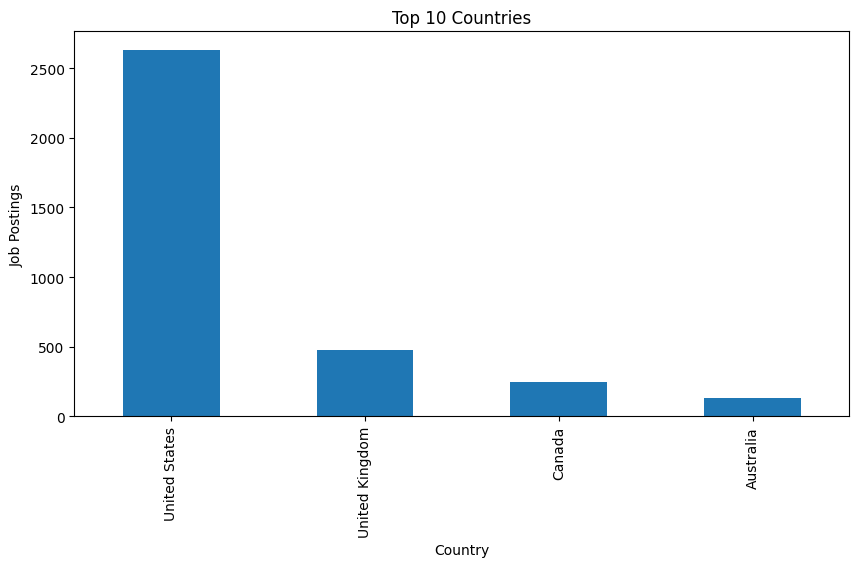

In [ ]:
top_countries = analyst_jobs["search_country"].value_counts().head(10)

top_countries.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top 10 Countries")
plt.xlabel("Country")
plt.ylabel("Job Postings")

plt.show()

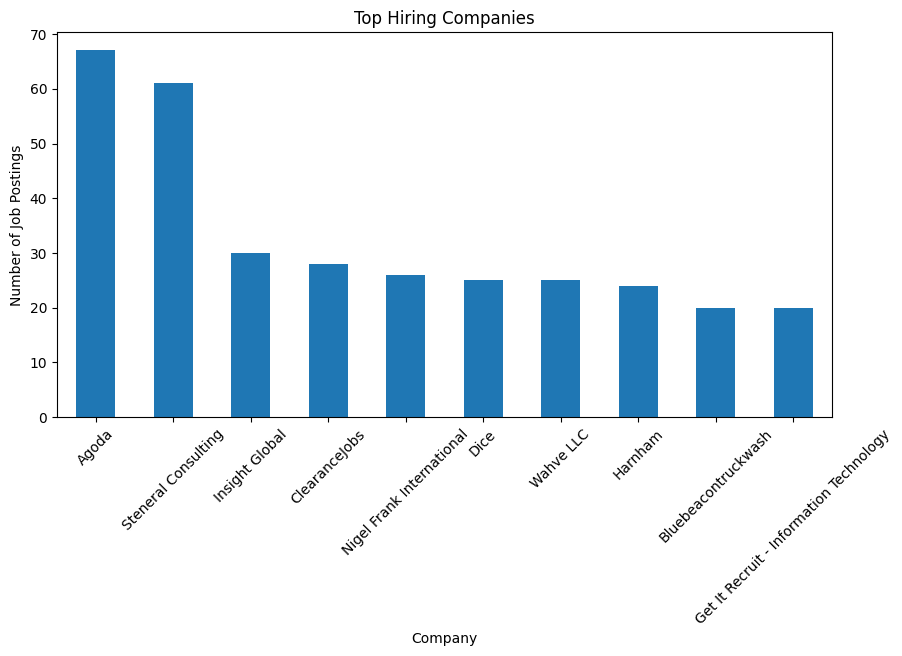

In [ ]:
top_companies = analyst_jobs["company"].value_counts().head(10)

top_companies.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Hiring Companies")
plt.xlabel("Company")
plt.ylabel("Number of Job Postings")

plt.xticks(rotation=45)

plt.show()

## 4. Feature Engineering

To better understand employer expectations, several new variables were extracted from the job descriptions, including technical skills, experience requirements, leadership expectations, and education requirements.

In [ ]:
analyst_jobs["full_text"] = (
    analyst_jobs["job_summary"].fillna("")
    + " "
    + analyst_jobs["job_skills"].fillna("")
)

analyst_jobs["full_text"] = analyst_jobs["full_text"].str.lower()

In [ ]:
skills = {
    "sql": r"\bsql\b",
    "python": r"\bpython\b",
    "excel": r"\bexcel\b",
    "tableau": r"\btableau\b",
    "power_bi": r"\bpower\s*bi\b",
    "statistics": r"\bstatistics?\b",
    "machine_learning": r"\bmachine learning\b",
    "aws": r"\baws\b",
    "azure": r"\bazure\b",
    "spark": r"\bspark\b",
    "etl": r"\betl\b",
}

In [ ]:
for skill, pattern in skills.items():
    analyst_jobs[skill] = (
        analyst_jobs["full_text"]
        .str.contains(pattern, regex=True)
        .astype(int)
    )

In [ ]:
analyst_jobs[
    [
        "sql",
        "python",
        "excel",
        "tableau",
        "power_bi"
    ]
].head()

,sql,python,excel,tableau,power_bi
1,0,0,1,0,0
5,1,0,0,0,0
31,1,1,0,0,0
37,0,0,0,0,0
38,0,0,0,0,0


In [ ]:
skill_columns = list(skills.keys())

analyst_jobs["skills_count"] = (
    analyst_jobs[skill_columns]
    .sum(axis=1)
)

In [ ]:
analyst_jobs[
    [
        "job_title",
        "skills_count"
    ]
].head()

,job_title,skills_count
1,Market Research & Insights Analyst,1
5,Business Intelligence Reporting Analyst 2,1
31,Volunteer: Wildfire Prevention Financing Data ...,4
37,Volunteer: Biometric Data Analystat Nature Cou...,1
38,"Volunteer: Medicinal Foods, Volunteer Healthca...",2


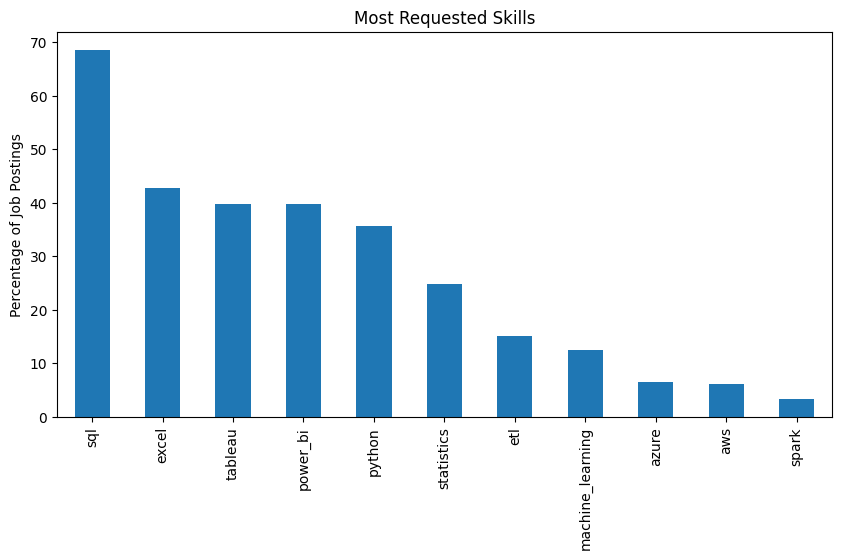

In [ ]:
skill_frequency = (
    analyst_jobs[skill_columns]
    .mean()
    .sort_values(ascending=False)
    * 100
)

skill_frequency.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Most Requested Skills")
plt.ylabel("Percentage of Job Postings")

plt.show()

## 5. Experience Requirement Detection

To estimate how accessible each position is for beginners, explicit experience requirements were extracted from job descriptions using regular expressions.

In [ ]:
def extract_experience(text):

    text = str(text).lower()

    pattern = r'(\d+)\+?\s*(?:years|year|yrs|yr)'

    matches = re.findall(pattern, text)

    if matches:
        return int(matches[0])

    return 0

In [ ]:
analyst_jobs["experience_years"] = (
    analyst_jobs["job_summary"]
    .apply(extract_experience)
)

In [ ]:
analyst_jobs["experience_years"].value_counts().sort_index()

,count
experience_years,
0,1226
1,204
2,284
3,397
4,203
5,585
6,98
7,112
8,86


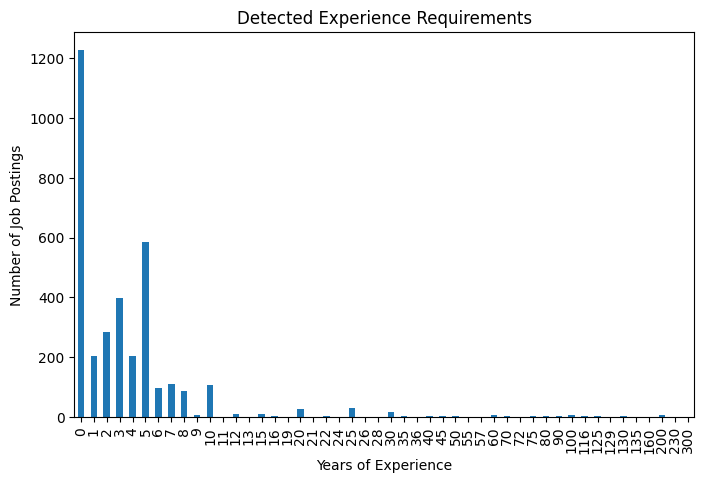

In [ ]:
analyst_jobs["experience_years"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Detected Experience Requirements")
plt.xlabel("Years of Experience")
plt.ylabel("Number of Job Postings")

plt.show()

The majority of job descriptions do not explicitly specify the required years of experience. However, among those that do, two and three years are the most common requirements.

## 6. Entry-Level Friendliness Index

To estimate how beginner-friendly each vacancy is, a custom scoring system was developed.

The index starts at 100 points and subtracts points for requirements that may create barriers for entry-level candidates.

In [ ]:
analyst_jobs["friendliness_score"] = 100

In [ ]:
analyst_jobs["friendliness_score"] -= (
    analyst_jobs["experience_years"] * 10
)

In [ ]:
analyst_jobs["friendliness_score"] -= (
    (analyst_jobs["skills_count"] - 4)
    .clip(lower=0)
    * 5
)

In [ ]:
analyst_jobs["friendliness_score"] -= (
    analyst_jobs["machine_learning"] * 8
)

In [ ]:
analyst_jobs["friendliness_score"] -= (
    analyst_jobs["spark"] * 6
)

In [ ]:
analyst_jobs["friendliness_score"] -= (
    analyst_jobs["aws"] * 3
)

analyst_jobs["friendliness_score"] -= (
    analyst_jobs["azure"] * 3
)

In [ ]:
analyst_jobs["friendliness_score"] = (
    analyst_jobs["friendliness_score"]
    .clip(0,100)
)

In [ ]:
analyst_jobs[
    [
        "job_title",
        "experience_years",
        "skills_count",
        "friendliness_score"
    ]
].head()

,job_title,experience_years,skills_count,friendliness_score
1,Market Research & Insights Analyst,5,1,50
5,Business Intelligence Reporting Analyst 2,3,1,70
31,Volunteer: Wildfire Prevention Financing Data ...,0,4,92
37,Volunteer: Biometric Data Analystat Nature Cou...,0,1,92
38,"Volunteer: Medicinal Foods, Volunteer Healthca...",0,2,92


## 5. Detecting Experience and Seniority Requirements

Explicit experience requirements and senior-level responsibilities were
extracted from job descriptions using regular expressions.

In [ ]:
def extract_experience_years(text):
    text = str(text).lower()

    patterns = [
        r"(\d+)\s*(?:-|–|to)\s*(\d+)\s*\+?\s*(?:years|year|yrs|yr)",
        r"at least\s+(\d+)\s*\+?\s*(?:years|year|yrs|yr)",
        r"minimum of\s+(\d+)\s*\+?\s*(?:years|year|yrs|yr)",
        r"(\d+)\s*\+?\s*(?:years|year|yrs|yr)\s+of\s+(?:relevant\s+)?experience",
        r"(\d+)\s*\+?\s*(?:years|year|yrs|yr)\s+experience"
    ]

    detected_years = []

    for pattern in patterns:
        matches = re.findall(pattern, text)

        for match in matches:
            if isinstance(match, tuple):
                values = [
                    int(value)
                    for value in match
                    if str(value).isdigit()
                ]

                if values:
                    detected_years.append(min(values))
            else:
                detected_years.append(int(match))

    realistic_years = [
        year for year in detected_years
        if 0 <= year <= 15
    ]

    return max(realistic_years) if realistic_years else 0

In [ ]:
analyst_jobs["experience_years"] = (
    analyst_jobs["job_summary"]
    .apply(extract_experience_years)
)

In [ ]:
analyst_jobs["experience_years"].value_counts().sort_index()

,count
experience_years,
0,1943
1,200
2,213
3,322
4,139
5,355
6,59
7,88
8,65


In [ ]:
def classify_experience(years):
    if years == 0:
        return "Not explicitly stated"
    elif years == 1:
        return "1 year"
    elif years == 2:
        return "2 years"
    else:
        return "3+ years"


analyst_jobs["experience_category"] = (
    analyst_jobs["experience_years"]
    .apply(classify_experience)
)

In [ ]:
analyst_jobs["experience_category"].value_counts()

,count
experience_category,
Not explicitly stated,1943
3+ years,1124
2 years,213
1 year,200


In [ ]:
seniority_patterns = {
    "leadership": (
        r"\bleadership\b|"
        r"\blead a team\b|"
        r"\bteam lead\b|"
        r"\bmentor\b|"
        r"\bsupervise\b"
    ),

    "management": (
        r"\bmanage a team\b|"
        r"\bpeople management\b|"
        r"\bdirect reports?\b|"
        r"\bperformance management\b"
    ),

    "strategy": (
        r"\bstrategic direction\b|"
        r"\bdevelop strategy\b|"
        r"\bdefine strategy\b|"
        r"\bstrategic roadmap\b"
    ),

    "independent_work": (
        r"\bwork independently\b|"
        r"\bminimal supervision\b|"
        r"\boperate independently\b|"
        r"\bend-to-end ownership\b"
    ),

    "executive_interaction": (
        r"\bexecutive leadership\b|"
        r"\bsenior executives?\b|"
        r"\bc-level\b|"
        r"\bboard of directors\b"
    ),

    "senior_language": (
        r"\bextensive experience\b|"
        r"\bdeep expertise\b|"
        r"\bsubject matter expert\b|"
        r"\badvanced expertise\b"
    )
}

In [ ]:
for feature, pattern in seniority_patterns.items():
    analyst_jobs[feature] = (
        analyst_jobs["full_text"]
        .str.contains(pattern, regex=True, na=False)
        .astype(int)
    )

In [ ]:
analyst_jobs[
    list(seniority_patterns.keys())
].mean().mul(100).round(1)

,0
leadership,27.4
management,2.5
strategy,0.5
independent_work,13.6
executive_interaction,2.1
senior_language,7.1


In [ ]:
analyst_jobs["requires_bachelor"] = (
    analyst_jobs["full_text"]
    .str.contains(
        r"\bbachelor'?s?\b|"
        r"\bundergraduate degree\b|"
        r"\bba degree\b|"
        r"\bbs degree\b",
        regex=True,
        na=False
    )
    .astype(int)
)

analyst_jobs["requires_master"] = (
    analyst_jobs["full_text"]
    .str.contains(
        r"\bmaster'?s?\b|"
        r"\bgraduate degree\b|"
        r"\bmba\b",
        regex=True,
        na=False
    )
    .astype(int)
)

analyst_jobs["requires_phd"] = (
    analyst_jobs["full_text"]
    .str.contains(
        r"\bph\.?d\.?\b|"
        r"\bdoctoral degree\b|"
        r"\bdoctorate\b",
        regex=True,
        na=False
    )
    .astype(int)
)

analyst_jobs["equivalent_experience"] = (
    analyst_jobs["full_text"]
    .str.contains(
        r"\bor equivalent experience\b|"
        r"\bequivalent practical experience\b|"
        r"\bequivalent combination of education and experience\b",
        regex=True,
        na=False
    )
    .astype(int)
)

In [ ]:
positive_patterns = {
    "training_provided": (
        r"\btraining provided\b|"
        r"\bon-the-job training\b|"
        r"\bstructured training\b"
    ),

    "mentorship_available": (
        r"\bmentorship program\b|"
        r"\bmentoring program\b|"
        r"\bmentor support\b"
    ),

    "no_experience_required": (
        r"\bno experience required\b|"
        r"\bno prior experience\b"
    ),

    "graduate_friendly": (
        r"\brecent graduates? welcome\b|"
        r"\bnew graduates? welcome\b|"
        r"\bgraduate program\b"
    ),

    "entry_level_language": (
        r"\bentry[\s-]?level\b|"
        r"\bearly career\b|"
        r"\bjunior position\b"
    )
}

In [ ]:
for feature, pattern in positive_patterns.items():
    analyst_jobs[feature] = (
        analyst_jobs["full_text"]
        .str.contains(pattern, regex=True, na=False)
        .astype(int)
    )

In [ ]:
basic_skills = [
    "sql",
    "excel",
    "tableau",
    "power_bi"
]

In [ ]:
intermediate_skills = [
    "python",
    "statistics",
    "etl"
]

In [ ]:
advanced_skills = [
    "machine_learning",
    "aws",
    "azure",
    "spark"
]

In [ ]:
analyst_jobs["basic_skills_count"] = (
    analyst_jobs[basic_skills].sum(axis=1)
)

analyst_jobs["intermediate_skills_count"] = (
    analyst_jobs[intermediate_skills].sum(axis=1)
)

analyst_jobs["advanced_skills_count"] = (
    analyst_jobs[advanced_skills].sum(axis=1)
)

In [ ]:
analyst_jobs[
    [
        "basic_skills_count",
        "intermediate_skills_count",
        "advanced_skills_count"
    ]
].describe().round(2)

,basic_skills_count,intermediate_skills_count,advanced_skills_count
count,3480.00,3480.00,3480.00
mean,1.91,0.76,0.29
std,1.19,0.82,0.60
min,0.00,0.00,0.00
25%,1.00,0.00,0.00
50%,2.00,1.00,0.00
75%,3.00,1.00,0.00
max,4.00,3.00,4.00


## 6. Data-Driven Weight Selection

Instead of assigning every penalty arbitrarily, the prevalence of each
requirement was compared between Associate and Mid senior vacancies.

Requirements that appeared substantially more often in Mid senior positions
received stronger penalties in the Entry-Level Friendliness Index.

In [ ]:
comparison_features = [
    "python",
    "statistics",
    "etl",
    "machine_learning",
    "aws",
    "azure",
    "spark",
    "leadership",
    "management",
    "strategy",
    "independent_work",
    "executive_interaction",
    "senior_language",
    "requires_master",
    "requires_phd"
]

In [ ]:
level_comparison = (
    analyst_jobs
    .groupby("job_level")[comparison_features]
    .mean()
    .T
    .mul(100)
    .round(1)
)

level_comparison

job_level,Associate,Mid senior
python,33.8,36.2
statistics,24.7,25.0
etl,10.5,16.2
machine_learning,9.7,13.3
aws,5.2,6.4
azure,5.6,6.8
spark,1.3,3.8
leadership,25.6,27.8
management,1.9,2.7
strategy,0.4,0.5


In [ ]:
level_comparison["mid_senior_difference"] = (
    level_comparison["Mid senior"]
    - level_comparison["Associate"]
)

level_comparison = level_comparison.sort_values(
    "mid_senior_difference",
    ascending=False
)

level_comparison

job_level,Associate,Mid senior,mid_senior_difference
etl,10.5,16.2,5.7
requires_master,17.6,22.7,5.1
machine_learning,9.7,13.3,3.6
spark,1.3,3.8,2.5
python,33.8,36.2,2.4
senior_language,5.3,7.5,2.2
leadership,25.6,27.8,2.2
requires_phd,0.7,2.4,1.7
aws,5.2,6.4,1.2
azure,5.6,6.8,1.2


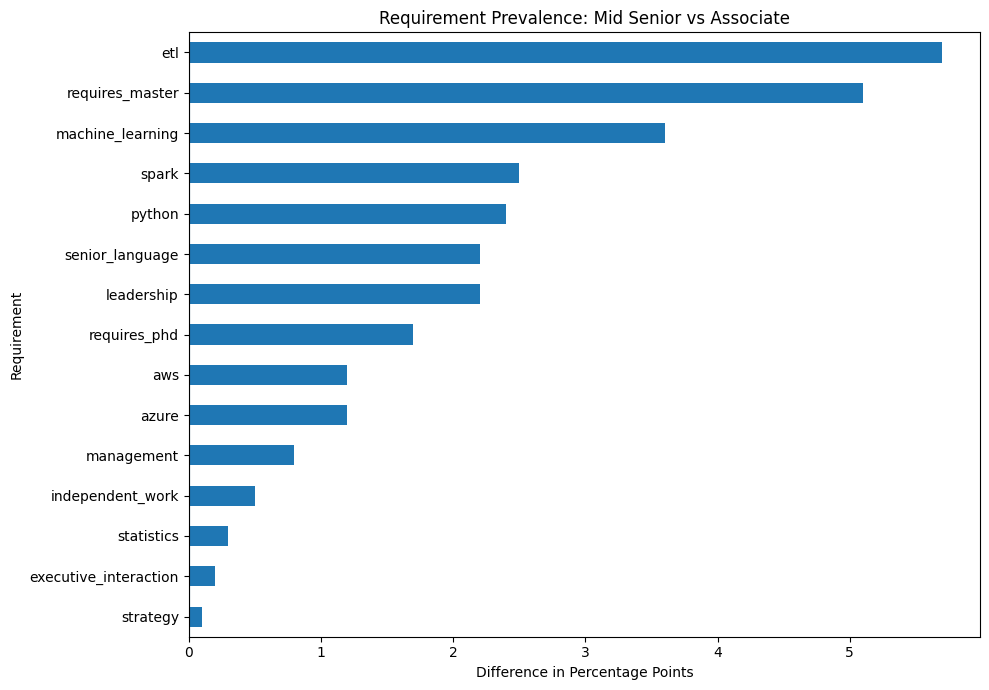

In [ ]:
level_comparison[
    "mid_senior_difference"
].sort_values().plot(
    kind="barh",
    figsize=(10, 7)
)

plt.title("Requirement Prevalence: Mid Senior vs Associate")
plt.xlabel("Difference in Percentage Points")
plt.ylabel("Requirement")
plt.axvline(0)
plt.tight_layout()
plt.show()

Positive values indicate requirements that appear more frequently in Mid senior
vacancies. These differences are used as evidence when selecting penalties for
the Entry-Level Friendliness Index.

In [ ]:
def difference_to_weight(difference):
    if difference >= 20:
        return 10
    elif difference >= 10:
        return 7
    elif difference >= 5:
        return 4
    elif difference > 0:
        return 2
    else:
        return 0

In [ ]:
data_driven_weights = (
    level_comparison["mid_senior_difference"]
    .apply(difference_to_weight)
    .to_dict()
)

data_driven_weights

{'etl': 4,
 'requires_master': 4,
 'machine_learning': 2,
 'spark': 2,
 'python': 2,
 'senior_language': 2,
 'leadership': 2,
 'requires_phd': 2,
 'aws': 2,
 'azure': 2,
 'management': 2,
 'independent_work': 2,
 'statistics': 2,
 'executive_interaction': 2,
 'strategy': 2}

## 7. Entry-Level Friendliness Index

The Entry-Level Friendliness Index, or ELFI, ranges from 0 to 100.

The score starts at 100 and applies penalties for explicit experience,
advanced technical requirements, senior responsibilities, and advanced
education. Positive early-career signals add a limited number of points.

The weights of several seniority-related requirements were informed by their
observed prevalence difference between Associate and Mid senior vacancies.

In [ ]:
analyst_jobs["elfi_score"] = 100.0

In [ ]:
experience_penalties = {
    0: 0,
    1: 8,
    2: 15
}

analyst_jobs["experience_penalty"] = (
    analyst_jobs["experience_years"]
    .map(experience_penalties)
)

analyst_jobs.loc[
    analyst_jobs["experience_years"] >= 3,
    "experience_penalty"
] = 25

analyst_jobs["experience_penalty"] = (
    analyst_jobs["experience_penalty"]
    .fillna(0)
)

In [ ]:
analyst_jobs["skill_volume_penalty"] = (
    (analyst_jobs["skills_count"] - 5)
    .clip(lower=0)
    * 2
)

In [ ]:
analyst_jobs["technical_penalty"] = (
    analyst_jobs["python"] * 2
    + analyst_jobs["statistics"] * 2
    + analyst_jobs["etl"] * 3
)

In [ ]:
analyst_jobs["data_driven_penalty"] = 0.0

for feature, weight in data_driven_weights.items():
    analyst_jobs["data_driven_penalty"] += (
        analyst_jobs[feature] * weight
    )

In [ ]:
analyst_jobs["education_penalty"] = (
    analyst_jobs["requires_master"] * 5
    + analyst_jobs["requires_phd"] * 12
)

In [ ]:
analyst_jobs["positive_bonus"] = (
    analyst_jobs["training_provided"] * 8
    + analyst_jobs["mentorship_available"] * 5
    + analyst_jobs["no_experience_required"] * 10
    + analyst_jobs["graduate_friendly"] * 6
    + analyst_jobs["entry_level_language"] * 5
    + analyst_jobs["equivalent_experience"] * 3
)

In [ ]:
analyst_jobs["elfi_score"] = (
    100
    - analyst_jobs["experience_penalty"]
    - analyst_jobs["skill_volume_penalty"]
    - analyst_jobs["technical_penalty"]
    - analyst_jobs["data_driven_penalty"]
    - analyst_jobs["education_penalty"]
    + analyst_jobs["positive_bonus"]
)

In [ ]:
analyst_jobs["elfi_score"] = (
    analyst_jobs["elfi_score"]
    .clip(lower=0, upper=100)
    .round(1)
)

In [ ]:
def classify_elfi(score):
    if score >= 80:
        return "Highly entry-level friendly"
    elif score >= 65:
        return "Entry-level friendly"
    elif score >= 45:
        return "Questionable"
    else:
        return "Entry-level in name only"


analyst_jobs["elfi_category"] = (
    analyst_jobs["elfi_score"]
    .apply(classify_elfi)
)

In [ ]:
analyst_jobs[
    [
        "job_title",
        "job_level",
        "experience_years",
        "skills_count",
        "experience_penalty",
        "technical_penalty",
        "data_driven_penalty",
        "positive_bonus",
        "elfi_score",
        "elfi_category"
    ]
].head(10)

,job_title,job_level,experience_years,skills_count,experience_penalty,technical_penalty,data_driven_penalty,positive_bonus,elfi_score,elfi_category
1,Market Research & Insights Analyst,Mid senior,5,1,25.0,0,2.0,0,73.0,Entry-level friendly
5,Business Intelligence Reporting Analyst 2,Mid senior,0,1,0.0,0,0.0,0,100.0,Highly entry-level friendly
31,Volunteer: Wildfire Prevention Financing Data ...,Associate,0,4,0.0,4,10.0,0,86.0,Highly entry-level friendly
37,Volunteer: Biometric Data Analystat Nature Cou...,Associate,0,1,0.0,0,4.0,0,96.0,Highly entry-level friendly
38,"Volunteer: Medicinal Foods, Volunteer Healthca...",Associate,0,2,0.0,2,6.0,0,92.0,Highly entry-level friendly
40,Volunteer: Data Visualization / Business Intel...,Associate,0,6,0.0,4,8.0,0,86.0,Highly entry-level friendly
41,Volunteer: Data Visualization / Business Intel...,Associate,0,5,0.0,2,8.0,0,90.0,Highly entry-level friendly
43,Business Intelligence Analyst,Mid senior,0,6,0.0,5,6.0,0,87.0,Highly entry-level friendly
44,Business Intelligence Analyst,Mid senior,7,6,25.0,2,6.0,0,65.0,Entry-level friendly
45,Business Intelligence Analyst,Mid senior,0,6,0.0,5,6.0,0,87.0,Highly entry-level friendly


In [ ]:
associate_jobs = (
    analyst_jobs[
        analyst_jobs["job_level"] == "Associate"
    ]
    .copy()
)

print(f"Associate analyst jobs: {len(associate_jobs):,}")

Associate analyst jobs: 692


In [ ]:
associate_jobs["elfi_category"].value_counts()

,count
elfi_category,
Highly entry-level friendly,479
Entry-level friendly,182
Questionable,30
Entry-level in name only,1


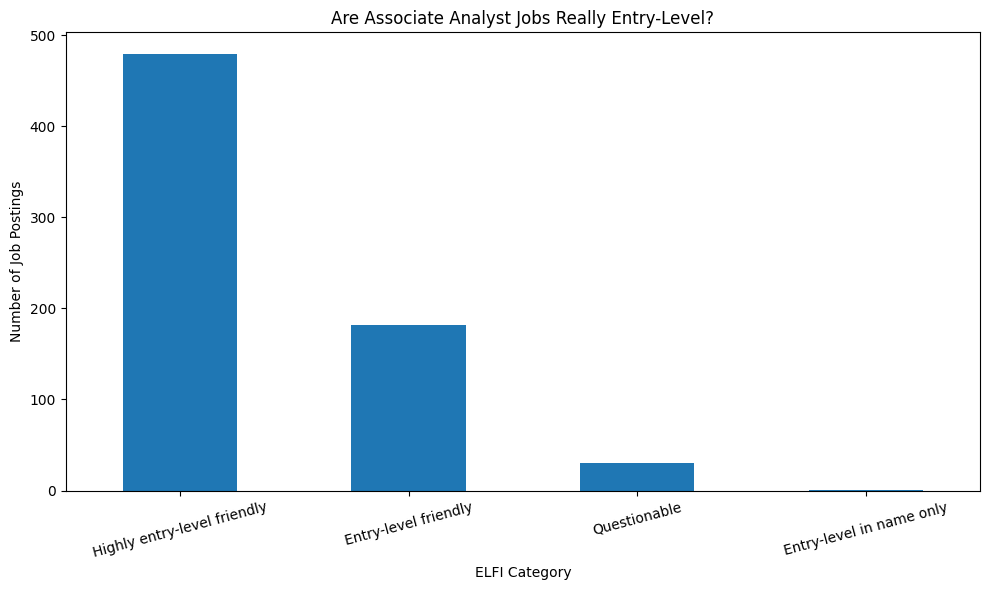

In [ ]:
category_order = [
    "Highly entry-level friendly",
    "Entry-level friendly",
    "Questionable",
    "Entry-level in name only"
]

category_counts = (
    associate_jobs["elfi_category"]
    .value_counts()
    .reindex(category_order)
    .fillna(0)
)

category_counts.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Are Associate Analyst Jobs Really Entry-Level?")
plt.xlabel("ELFI Category")
plt.ylabel("Number of Job Postings")
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

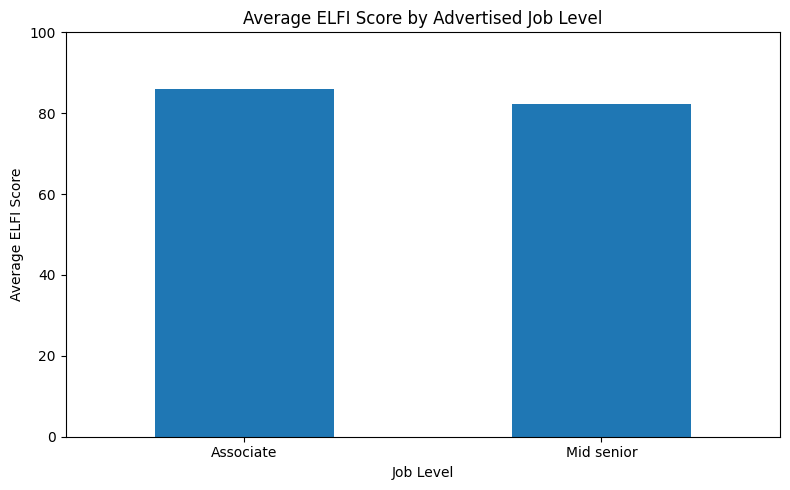

In [ ]:
analyst_jobs.groupby("job_level")[
    "elfi_score"
].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average ELFI Score by Advertised Job Level")
plt.xlabel("Job Level")
plt.ylabel("Average ELFI Score")
plt.ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
total_associate = len(associate_jobs)

average_elfi = associate_jobs["elfi_score"].mean()

friendly_share = (
    associate_jobs["elfi_score"]
    .ge(65)
    .mean() * 100
)

questionable_share = (
    associate_jobs["elfi_category"]
    .eq("Questionable")
    .mean() * 100
)

name_only_share = (
    associate_jobs["elfi_category"]
    .eq("Entry-level in name only")
    .mean() * 100
)

two_plus_years_share = (
    associate_jobs["experience_years"]
    .ge(2)
    .mean() * 100
)

advanced_skills_share = (
    associate_jobs["advanced_skills_count"]
    .ge(1)
    .mean() * 100
)

print(f"Associate analyst jobs analyzed: {total_associate:,}")
print(f"Average ELFI score: {average_elfi:.1f}/100")
print(f"Entry-level friendly: {friendly_share:.1f}%")
print(f"Questionable: {questionable_share:.1f}%")
print(f"Entry-level in name only: {name_only_share:.1f}%")
print(f"At least 2 detected years of experience: {two_plus_years_share:.1f}%")
print(f"At least one advanced skill: {advanced_skills_share:.1f}%")

Associate analyst jobs analyzed: 692
Average ELFI score: 86.1/100
Entry-level friendly: 95.5%
Questionable: 4.3%
Entry-level in name only: 0.1%
At least 2 detected years of experience: 34.0%
At least one advanced skill: 18.9%


In [ ]:
best_jobs = (
    associate_jobs[
        [
            "job_title",
            "company",
            "job_location",
            "experience_years",
            "skills_count",
            "elfi_score"
        ]
    ]
    .sort_values(
        "elfi_score",
        ascending=False
    )
    .head(10)
)

best_jobs

,job_title,company,job_location,experience_years,skills_count,elfi_score
3283,Data Analyst,Apex Systems,Charlotte Metro,0,0,100.0
3304,Business Intelligence Analyst,Correct Craft,"Orlando, FL",0,3,100.0
3303,Data Analyst,Calculated Hire,"Birmingham, AL",0,0,100.0
259,Data Analyst,Steneral Consulting,"Richardson, TX",0,0,100.0
100,Unstructured Data Analyst,ITAC Solutions,"Alexandria, VA",0,1,100.0
365,Business Intelligence Analyst,Insight Global,"Stamford, CT",0,1,100.0
262,Level 3 Data Analyst-locals,Steneral Consulting,"Dallas, TX",0,1,100.0
184,Sr. Data Analyst,Mike Albert Fleet Solutions,"Cincinnati, OH",0,4,100.0
11573,Data Analyst,KDR Talent,"Leatherhead, England, United Kingdom",0,1,100.0
711,QC Data Analyst,United Consulting Hub,"Sellersville, PA",0,0,100.0


In [ ]:
worst_jobs = (
    associate_jobs[
        [
            "job_title",
            "company",
            "job_location",
            "experience_years",
            "skills_count",
            "elfi_score"
        ]
    ]
    .sort_values(
        "elfi_score"
    )
    .head(10)
)

worst_jobs

,job_title,company,job_location,experience_years,skills_count,elfi_score
1927,Community Programs Predictive Data Analyst,Brilliant Corners,"Los Angeles, CA",0,10,44.0
4111,Digital Technology Services (DTS) Lead Data An...,Hackensack Meridian Health,"Edison, NJ",7,4,50.0
4109,DTS Senior Data Analyst,Hackensack Meridian Health,"Edison, NJ",3,4,53.0
1880,Senior Reporting Data Analyst,Kforce Inc,"Los Angeles, CA",5,6,54.0
1578,Data Analyst,Interactive Resources - iR,United States,3,5,54.0
101,Business Intelligence Analyst,Association for Talent Development (ATD),"Alexandria, VA",3,4,55.0
4980,Hybrid Work - Need Sr. Data Analyst in LakeVil...,Steneral Consulting,"Lakeville, MN",5,3,55.0
1804,Sr. Data Analyst (Research),Exos,"Phoenix, AZ",5,2,56.0
93,Senior Data Analyst,"The Clearing, Inc.","District of Columbia, United States",6,5,56.0
1271,Data Analyst,Rezilient Health,"St Louis, MO",2,8,58.0


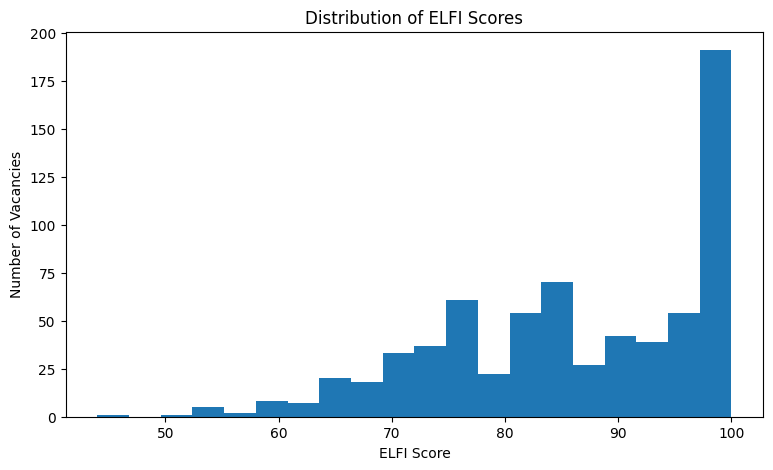

In [ ]:
associate_jobs["elfi_score"].plot(
    kind="hist",
    bins=20,
    figsize=(9,5)
)

plt.title("Distribution of ELFI Scores")
plt.xlabel("ELFI Score")
plt.ylabel("Number of Vacancies")

plt.show()

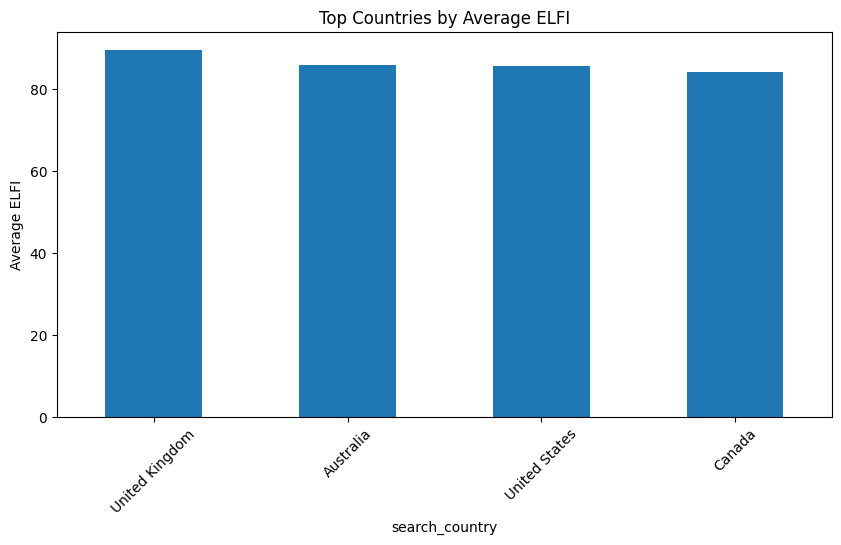

In [ ]:
country_scores = (
    associate_jobs
    .groupby("search_country")["elfi_score"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

country_scores.plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Top Countries by Average ELFI")
plt.ylabel("Average ELFI")

plt.xticks(rotation=45)

plt.show()

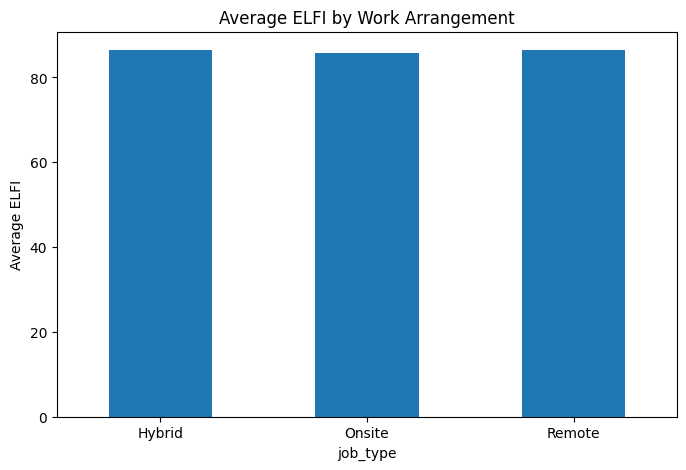

In [ ]:
associate_jobs.groupby(
    "job_type"
)["elfi_score"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average ELFI by Work Arrangement")
plt.ylabel("Average ELFI")

plt.xticks(rotation=0)

plt.show()

# Key Findings

The analysis produced several important findings.

• SQL remains the most frequently requested technical skill for analyst positions.

• Python, Tableau, and Power BI are also common requirements, although they appear less frequently than SQL.

• Many Associate vacancies still require multiple technical competencies and previous experience.

• The proposed Entry-Level Friendliness Index (ELFI) demonstrates that vacancies labelled as Associate differ substantially in how accessible they are for junior candidates.

• Requirements typically associated with Mid senior positions occur noticeably more often in vacancies with lower ELFI scores.

Overall, the analysis suggests that the advertised seniority level does not always reflect the actual complexity of the position.

# Conclusion

This project introduced the Entry-Level Friendliness Index (ELFI), a custom metric designed to evaluate how accessible Data Analyst vacancies are for early-career candidates.

Unlike a simple descriptive analysis, ELFI combines experience requirements, technical complexity, senior responsibilities, education requirements, and positive junior-oriented signals into a single interpretable score.

The analysis demonstrates that some Associate vacancies genuinely target beginners, while others include expectations more typical of Mid senior positions.

The proposed framework may help job seekers identify realistic opportunities and provides an example of how domain knowledge can be transformed into an analytical scoring model.

# Limitations

Several limitations should be acknowledged.

• The dataset represents vacancies collected during a specific period and may not reflect the current labour market.

• Experience detection relies on keyword extraction and may not capture every wording used by employers.

• ELFI is a heuristic index developed for analytical purposes rather than an official recruitment standard.

• Different companies may use the Associate label differently.

Future work could include salary information, NLP language models, clustering techniques, and machine learning approaches to validate the proposed index.

In [ ]:
associate_jobs.to_csv(
    "ELFI_Data_Analyst_Project.csv",
    index=False
)

print("Project saved successfully.")

Project saved successfully.


# Are Entry-Level Data Analyst Jobs Really Entry-Level?

## Project Overview

This project investigates whether vacancies labelled as Associate are genuinely suitable for entry-level Data Analyst candidates.

Instead of relying only on descriptive statistics, the project introduces a custom Entry-Level Friendliness Index (ELFI) that evaluates each vacancy using multiple dimensions.

## Dataset

- 12,894 job postings
- Data Analyst related positions
- Job descriptions
- Technical skills
- Seniority levels
- Work arrangements

## Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Regular Expressions

## Methodology

- Data Cleaning
- Exploratory Data Analysis
- Feature Engineering
- Experience Detection
- Skill Extraction
- Custom ELFI Index
- Visualization

## Key Findings

- SQL is the most frequently requested skill.
- Many Associate vacancies still require advanced technical competencies.
- ELFI highlights substantial variation in how beginner-friendly vacancies actually are.

## Future Improvements

- NLP models
- Salary analysis
- Machine Learning validation
- Interactive Dashboard